In [1]:
# ============================================================================
#  Cell 1 -- imports
# ============================================================================
import numpy as np
import matplotlib.pyplot as plt
from CoolProp.CoolProp import PropsSI

import caldis
from caldis.core.system import System
from caldis.components import FluidBoundary
from caldis.components.vessels.tank import Tank        # composite: fluid volume + wall
from caldis.fluids import CoolPropBackend
from caldis.solvers.dynamic import simulate

print("Caldis version:", caldis.__version__)

Caldis version: 0.2.0


In [7]:
# ============================================================================
#  Cell 2 -- build the system: an air stream heats a closed tank
# ============================================================================
# A Tank is a COMPOSITE: a fluid control volume (states M, U -> mass and energy)
# plus a wall (a thermal mass, state T). A heater warms the wall, the wall warms
# the fluid. We watch how the tank temperature and pressure evolve in time.
be = CoolPropBackend("Air")

p0, T0 = 1.0e5, 293.15                 # initial tank state: 1 bar, 20 C
h0 = PropsSI("H", "P", p0, "T", T0, "Air")

tank = Tank("tank", backend=be, V=0.05,          # 50 L rigid volume
            p_init=p0, h_init=h0,
            C_wall=800.0,                        # wall heat capacity [J/K]
            T_wall_init=T0,
            UA_wall=30.0,                        # wall<->fluid conductance [W/K]
            Q_heater=150.0)                      # heater on the wall [W]

# closed tank: a feed with zero flow on each port (nothing enters or leaves)
feed = FluidBoundary("feed", mdot=-0.01, h=h0, backend=be)
cap  = FluidBoundary("cap",  mdot=0.0, backend=be)   # closed end

sys_ = System("heated_tank")
sys_.add(tank, feed, cap)
sys_.connect(feed.port, tank.inl)
sys_.connect(tank.out, cap.port)

Connection(tank.fluid.out <-> cap.port)

In [8]:
# ============================================================================
#  Cell 3 -- run the dynamic simulation
# ============================================================================
# simulate() integrates the state equations (M.der, U.der, T.der) over time.
# init="steady" would start from a steady state; here the tank is NOT at steady
# state (it heats up forever with the heater on), so we start from the built
# initial state with init=None.
res = simulate(sys_, t_end=600.0, dt=5.0, init=None)

print("simulated", len(res.time), "time steps up to", res.time[-1], "s")

simulated 121 time steps up to 600.0 s


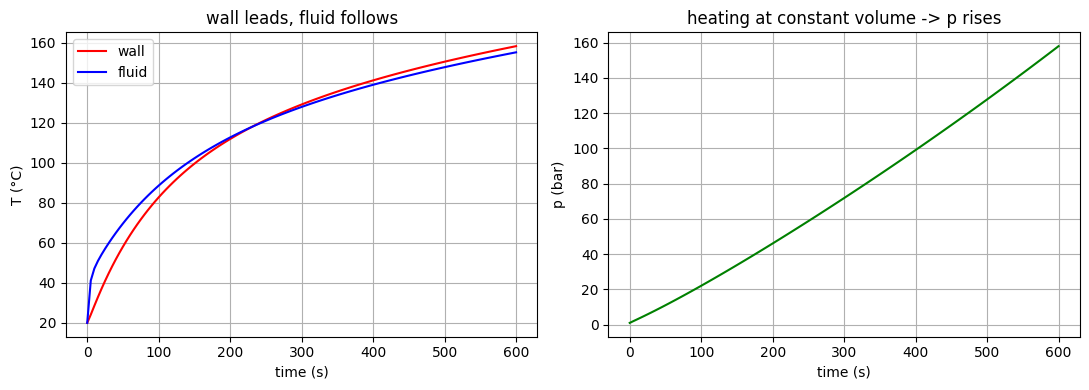

final fluid T = 155.2 °C  (started 20)
final wall  T = 158.3 °C
final p       = 157.947 bar


In [9]:
# ============================================================================
#  Cell 4 -- read and plot the results
# ============================================================================
# Results gives time series by hierarchical name: res.<component>.<...>
t = res.time
T_fluid = res.tank.fluid.T          # fluid temperature series [K]
T_wall  = res.tank.wall.T           # wall temperature series [K]
p_fluid = res.tank.fluid.p          # fluid pressure series [Pa]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t, T_wall - 273.15, 'r-', label="wall")
ax[0].plot(t, T_fluid - 273.15, 'b-', label="fluid")
ax[0].set_xlabel("time (s)"); ax[0].set_ylabel("T (°C)")
ax[0].legend(); ax[0].grid(True); ax[0].set_title("wall leads, fluid follows")
ax[1].plot(t, p_fluid / 1e5, 'g-')
ax[1].set_xlabel("time (s)"); ax[1].set_ylabel("p (bar)")
ax[1].grid(True); ax[1].set_title("heating at constant volume -> p rises")
fig.tight_layout(); plt.show()

print(f"final fluid T = {T_fluid[-1]-273.15:.1f} °C  (started {T0-273.15:.0f})")
print(f"final wall  T = {T_wall[-1]-273.15:.1f} °C")
print(f"final p       = {p_fluid[-1]/1e5:.3f} bar")